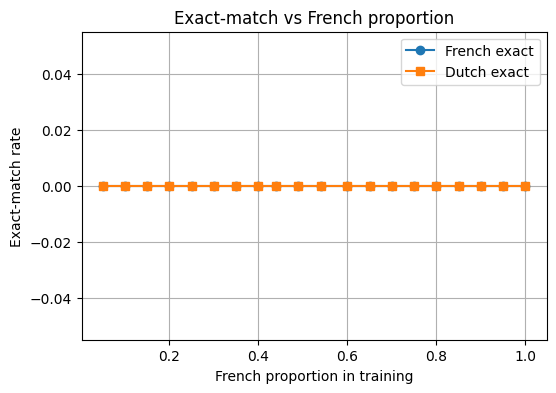

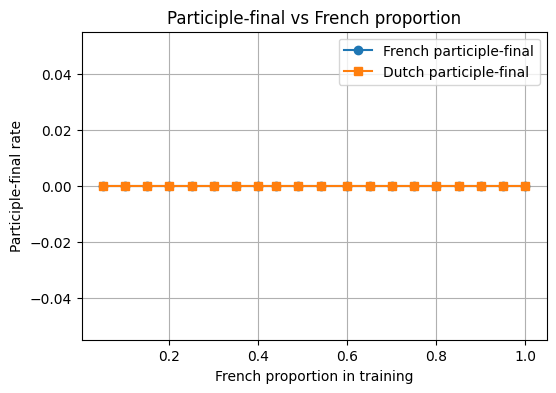

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Collect all metrics.json under interactive_results/*
records = []
for d in Path("interactive_results").glob("small_p*_run*"):
    # folder name looks like "small_p05_run0", "small_p10_run1", etc.
    _, prop_str, _ = d.name.split("_")
    prop = int(prop_str[1:]) / 100.0

    metrics_path = d / "metrics.json"
    if not metrics_path.exists():
        continue

    with open(metrics_path, encoding="utf-8") as f:
        m = json.load(f)

    records.append({
        "prop":           prop,
        "fr_exact":       m.get("fr_exact"),
        "nl_exact":       m.get("nl_exact"),
        "fr_part_final":  m.get("fr_part_final"),
        "nl_part_final":  m.get("nl_part_final"),
    })

# 2) Build DataFrame & sort by prop
df = pd.DataFrame(records).sort_values("prop")

# 3) Plot exact‐match curves
plt.figure(figsize=(6,4))
plt.plot(df["prop"], df["fr_exact"], marker="o", label="French exact")
plt.plot(df["prop"], df["nl_exact"], marker="s", label="Dutch exact")
plt.xlabel("French proportion in training")
plt.ylabel("Exact‐match rate")
plt.title("Exact‐match vs French proportion")
plt.legend()
plt.grid(True)
plt.show()

# 4) Plot participle‐final curves
plt.figure(figsize=(6,4))
plt.plot(df["prop"], df["fr_part_final"], marker="o", label="French participle‐final")
plt.plot(df["prop"], df["nl_part_final"], marker="s", label="Dutch participle‐final")
plt.xlabel("French proportion in training")
plt.ylabel("Participle‐final rate")
plt.title("Participle‐final vs French proportion")
plt.legend()
plt.grid(True)
plt.show()
